# Reinforcement Learning: A **policy-based** simple example 1
Scenario: Agent Navigating a **1D Grid**

A 1D world with 5 positions: [0, 1, 2, 3, 4 ]
- Start at position 0
- Objective: Maximize total reward, i.e. reach position 4 as quickly as possible. 
- Two actions: move right (1) or move left (0)
- Reward: +1 when reaching position 4, 0 otherwise (NOTE: no penalty here)
- Policy: Probability distribution over actions (or it can be a neural network) (here, we use softmax)

Here update rule is "Policy Gradient using REINFORCE algorithm"

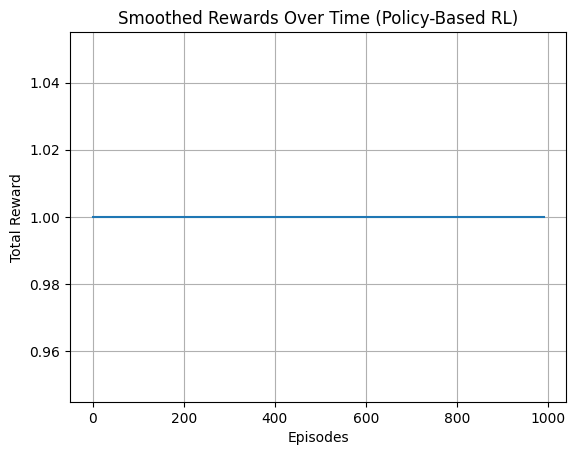

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Simple environment
class OneDGridEnv:
    def __init__(self, size=5):
        self.size = size
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 1:
            self.position = min(self.position + 1, self.size - 1)
        else:
            self.position = max(self.position - 1, 0)
        reward = 1 if self.position == self.size - 1 else 0
        done = (self.position == self.size - 1)
        return self.position, reward, done

# Policy agent using softmax policy and REINFORCE
class PolicyAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1):
        self.state_size = state_size
        self.action_size = action_size
        self.policy = np.random.rand(state_size, action_size)
        self.learning_rate = learning_rate

    def get_action_probs(self, state):
        z = self.policy[state]
        exp = np.exp(z - np.max(z))
        return exp / np.sum(exp)

    def choose_action(self, state):
        probs = self.get_action_probs(state)
        return np.random.choice(self.action_size, p=probs)

    def update_policy(self, episode):
        for state, action, reward in episode:
            probs = self.get_action_probs(state)
            grad = -probs
            grad[action] += 1  # ∇log(π(a|s))
            self.policy[state] += self.learning_rate * grad * reward

# Train the agent
env = OneDGridEnv()
agent = PolicyAgent(state_size=5, action_size=2)

EPISODES = 1000 # change to 100, 500, 1000,7000,15000
all_rewards = []
for episode_num in range(EPISODES):
    state = env.reset()
    episode = []
    done = False
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        episode.append((state, action, reward))
        state = next_state
    agent.update_policy(episode)
    total_reward = sum([r for _, _, r in episode])
    all_rewards.append(total_reward)

# Plot reward progress
plt.plot(np.convolve(all_rewards, np.ones(10)/10, mode='valid'))
plt.title("Smoothed Rewards Over Time (Policy-Based RL)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.grid()
plt.show()


### observation
Why Is the Total Reward Always 1?<br>
The only reward given is +1 when the agent reaches state 4. And the **agent always reaches state 4 in each episode (eventually)**. So: Every episode ends with a total reward of 1.

In [52]:
print(f"{'State':<6} {'P(Left)':<8} {'P(Right)':<8}")
for state in range(5):  # If you want to include the terminal state for completeness
    probs = agent.get_action_probs(state)
    print(f"{state:<6} {probs[0]:<8.2f} {probs[1]:<8.2f}")


State  P(Left)  P(Right)
0      0.36     0.64    
1      0.53     0.47    
2      0.50     0.50    
3      0.01     0.99    
4      0.47     0.53    


### Question: Why Are the Probabilities for “Left” High in some cases 
The Short Answer: The agent is still exploring, or it hasn't learned enough from the reward signal due to:
- Small gradients (from policy gradient update)
- Lack of penalties for bad actions (like going left)
- No negative rewards for wasting time

What's Causing This?: Let’s take a quick look at how the current learning is set up:
- Rewards are sparse (only +1 at the goal)
- Going left gives no feedback unless it delays reaching the goal
- The loss function only gets a useful signal at the end of an episode
- Policy updates use REINFORCE, which is high-variance and slow to converge

This leads to no strong pressure against going left—unless you:
- Penalize it
- Train for more episodes
- Use better reward shaping

Lets fix this by penalizing if moving away from goal

Episode 100 | Total Reward: 0.97
State  P(Left)  P(Right)
0      0.52     0.48    
1      0.28     0.72    
2      0.49     0.51    
3      0.36     0.64    
4      0.51     0.49    

Episode 200 | Total Reward: 0.82
State  P(Left)  P(Right)
0      0.50     0.50    
1      0.23     0.77    
2      0.41     0.59    
3      0.28     0.72    
4      0.51     0.49    

Episode 300 | Total Reward: 0.86
State  P(Left)  P(Right)
0      0.52     0.48    
1      0.20     0.80    
2      0.32     0.68    
3      0.25     0.75    
4      0.51     0.49    

Episode 400 | Total Reward: 0.86
State  P(Left)  P(Right)
0      0.46     0.54    
1      0.18     0.82    
2      0.29     0.71    
3      0.22     0.78    
4      0.51     0.49    

Episode 500 | Total Reward: 0.94
State  P(Left)  P(Right)
0      0.42     0.58    
1      0.16     0.84    
2      0.24     0.76    
3      0.20     0.80    
4      0.51     0.49    

Episode 600 | Total Reward: 0.91
State  P(Left)  P(Right)
0      0.36     0.64  

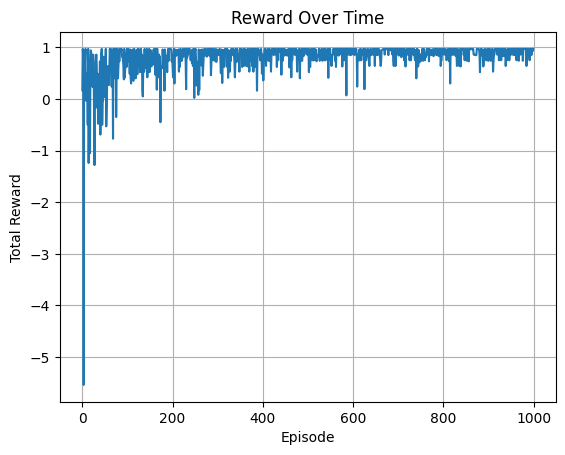

In [53]:
class OneDGridEnv:
    def __init__(self):
        self.state = 0
        self.done = False

    def reset(self):
        self.state = 0
        self.done = False
        return self.state

    def step(self, action):
        if self.done:
            raise ValueError("Episode has ended. Call reset() to start a new one.")

        prev_state = self.state

        # Action: 0 = left, 1 = right
        if action == 0:
            self.state = max(0, self.state - 1)
        elif action == 1:
            self.state = min(4, self.state + 1)

        # Small step penalty
        reward = -0.01

        # Penalize if moving away from goal
        if abs(self.state - 4) > abs(prev_state - 4):
            reward = -0.1

        # Reward for reaching goal
        if self.state == 4:
            reward = 1.0
            self.done = True

        return self.state, reward, self.done


class PolicyAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1):
        self.state_size = state_size
        self.action_size = action_size
        self.policy = np.random.rand(state_size, action_size)
        self.learning_rate = learning_rate

    def get_action_probs(self, state):
        z = self.policy[state]
        exp = np.exp(z - np.max(z))  # for numerical stability
        return exp / np.sum(exp)

    def choose_action(self, state):
        probs = self.get_action_probs(state)
        return np.random.choice(self.action_size, p=probs)

    def update(self, state, action, Gt):
        probs = self.get_action_probs(state)
        grad = -probs
        grad[action] += 1  # ∇log(π(a|s))
        self.policy[state] += self.learning_rate * grad * Gt


# Training Parameters
# EPISODES = 1000
gamma = 0.99

# Initialize environment and agent
env = OneDGridEnv()
agent = PolicyAgent(state_size=5, action_size=2, learning_rate=0.01)

episode_rewards = []

for episode in range(EPISODES):
    state = env.reset()
    done = False
    episode_data = []
    total_reward = 0

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        episode_data.append((state, action, reward))
        total_reward += reward
        state = next_state

    episode_rewards.append(total_reward)

    # Compute discounted returns
    G = 0
    returns = []
    for _, _, reward in reversed(episode_data):
        G = reward + gamma * G
        returns.insert(0, G)

    for (state, action, _), Gt in zip(episode_data, returns):
        agent.update(state, action, Gt)

    # Show policy every 100 episodes
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1} | Total Reward: {total_reward:.2f}")
        print(f"{'State':<6} {'P(Left)':<8} {'P(Right)':<8}")
        for s in range(5):
            probs = agent.get_action_probs(s)
            print(f"{s:<6} {probs[0]:<8.2f} {probs[1]:<8.2f}")
        print()

# Plot total reward
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Over Time")
plt.grid(True)
plt.show()


## Observation
The ***optimal policy*** is:<br>
At every state (positions 0 to 3), take action 1 → move right.<br>
**State 4 is terminal state. Although its showing a probability, it can be ignored or just change the range(5) -> range(4)**<br>
The agent should never move left. Doing so wastes steps and delays reaching the reward.